RMSD (Manual Formula, Core-Aligned)
Chain A  Min: 1.526 Å, Max: 2.411 Å, Avg: 1.873 Å
Chain B  Min: 1.806 Å, Max: 2.762 Å, Avg: 2.286 Å


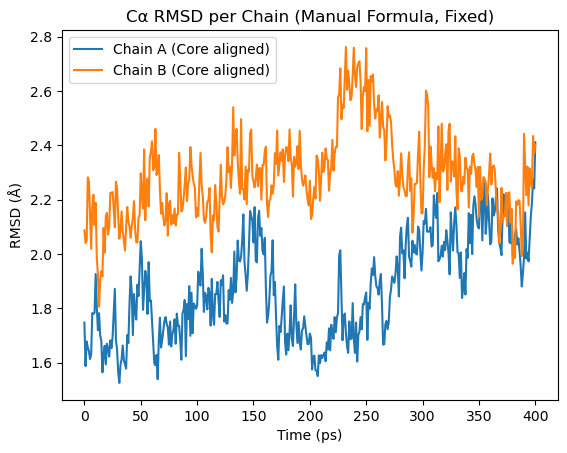

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


topology = "/home/malliga/md_analysis/conda_envs/dim.pat1.psf"
trajectory_file = "/home/malliga/md_analysis/conda_envs/prod_protein.xtc"
reference_file = "/home/malliga/md_analysis/conda_envs/em_protein.gro"


ref = mda.Universe(topology, reference_file)


trajA = mda.Universe(topology, trajectory_file)
trajB = mda.Universe(topology, trajectory_file)


core_residues = [
    13,14,15,16,17,18,19,30,31,32,33,34,35,
    71,72,74,110,111,112,113,114,115,116,117,
    118,119,120,161,163,177,178,179,180,181,
    182,183,184,185,186,187,188,189
]
core_res_str = " ".join(map(str, core_residues))

coreA_sel = f"segid 3CGA and resid {core_res_str} and name CA"
coreB_sel = f"segid 3CGB and resid {core_res_str} and name CA"

chainA_sel = "segid 3CGA and name CA"
chainB_sel = "segid 3CGB and name CA"

align.AlignTraj(trajA, ref, select=coreA_sel, in_memory=True).run()

ref_chainA = ref.select_atoms(chainA_sel).positions.copy()
chainA = trajA.select_atoms(chainA_sel)

rmsd_chainA = []
time_values = []

for ts in trajA.trajectory:
    diff = chainA.positions - ref_chainA
    rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))  # RMSD formula
    rmsd_chainA.append(rmsd)
    time_values.append(ts.time)

align.AlignTraj(trajB, ref, select=coreB_sel, in_memory=True).run()

ref_chainB = ref.select_atoms(chainB_sel).positions.copy()
chainB = trajB.select_atoms(chainB_sel)

rmsd_chainB = []

for ts in trajB.trajectory:
    diff = chainB.positions - ref_chainB
    rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))  # RMSD formula
    rmsd_chainB.append(rmsd)

df = pd.DataFrame({
    "Time (ps)": time_values,
    "RMSD_ChainA (Å)": rmsd_chainA,
    "RMSD_ChainB (Å)": rmsd_chainB
})

df.to_csv("rmsd_dimer_core_aligned_fixed.csv", index=False)

print("RMSD (Manual Formula, Core-Aligned)")
print(f"Chain A  Min: {np.min(rmsd_chainA):.3f} Å, Max: {np.max(rmsd_chainA):.3f} Å, Avg: {np.mean(rmsd_chainA):.3f} Å")
print(f"Chain B  Min: {np.min(rmsd_chainB):.3f} Å, Max: {np.max(rmsd_chainB):.3f} Å, Avg: {np.mean(rmsd_chainB):.3f} Å")


plt.figure()

plt.plot(time_values, rmsd_chainA, label="Chain A (Core aligned)")
plt.plot(time_values, rmsd_chainB, label="Chain B (Core aligned)")

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.title("Cα RMSD per Chain (Manual Formula, Fixed)")
plt.legend()

plt.savefig("rmsd_core_aligned_fixed.png", dpi=300)
plt.show()
plt.close()

RMSF (Core-Aligned per Chain)
Chain A Avg: 0.733 Å | Max: 3.013 Å
Chain B Avg: 0.757 Å | Max: 1.807 Å


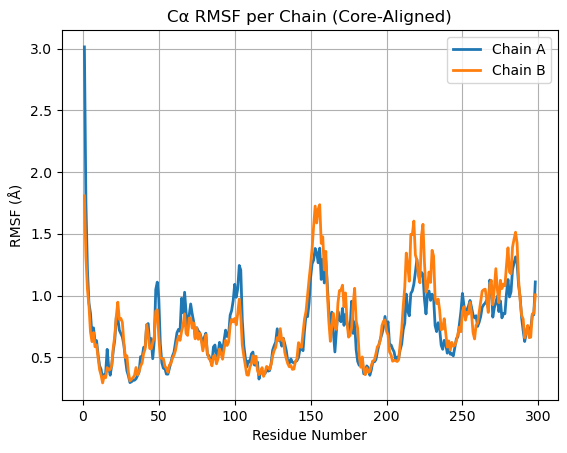

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

topology = "/home/malliga/md_analysis/conda_envs/dim.pat1.psf"
trajectory = "/home/malliga/md_analysis/conda_envs/prod_protein.xtc"
reference = "/home/malliga/md_analysis/conda_envs/em_protein.gro"


ref = mda.Universe(topology, reference)

trajA = mda.Universe(topology, trajectory)
trajB = mda.Universe(topology, trajectory)


core_residues = [
    13,14,15,16,17,18,19,30,31,32,33,34,35,
    71,72,74,110,111,112,113,114,115,116,117,
    118,119,120,161,163,177,178,179,180,181,
    182,183,184,185,186,187,188,189
]
core_str = " ".join(map(str, core_residues))

coreA_sel = f"segid 3CGA and resid {core_str} and name CA"
coreB_sel = f"segid 3CGB and resid {core_str} and name CA"

chainA_sel = "segid 3CGA and name CA"
chainB_sel = "segid 3CGB and name CA"


align.AlignTraj(trajA, ref, select=coreA_sel, in_memory=True).run()

chainA = trajA.select_atoms(chainA_sel)

posA = []
for ts in trajA.trajectory:
    posA.append(chainA.positions.copy())

posA = np.array(posA)

avgA = np.mean(posA, axis=0)
diffA = posA - avgA
rmsf_A = np.sqrt(np.mean(np.sum(diffA**2, axis=2), axis=0))

resids_A = chainA.resids

#Chain B

align.AlignTraj(trajB, ref, select=coreB_sel, in_memory=True).run()

chainB = trajB.select_atoms(chainB_sel)

posB = []
for ts in trajB.trajectory:
    posB.append(chainB.positions.copy())

posB = np.array(posB)

avgB = np.mean(posB, axis=0)
diffB = posB - avgB
rmsf_B = np.sqrt(np.mean(np.sum(diffB**2, axis=2), axis=0))

resids_B = chainB.resids


df = pd.DataFrame({
    "Residue_A": resids_A,
    "RMSF_ChainA (Å)": rmsf_A,
    "Residue_B": resids_B,
    "RMSF_ChainB (Å)": rmsf_B
})

df.to_csv("rmsf_chainA_chainB_core_aligned.csv", index=False)


print("RMSF (Core-Aligned per Chain)")
print(f"Chain A Avg: {np.mean(rmsf_A):.3f} Å | Max: {np.max(rmsf_A):.3f} Å")
print(f"Chain B Avg: {np.mean(rmsf_B):.3f} Å | Max: {np.max(rmsf_B):.3f} Å")


plt.figure()

plt.plot(resids_A, rmsf_A, lw=2, label="Chain A")
plt.plot(resids_B, rmsf_B, lw=2, label="Chain B")

plt.xlabel("Residue Number")
plt.ylabel("RMSF (Å)")
plt.title("Cα RMSF per Chain (Core-Aligned)")
plt.legend()
plt.grid(True)

plt.show()

Core RMSD (Manual Formula)
Chain A  Min: 1.284 Å, Max: 1.920 Å, Avg: 1.619 Å
Chain B  Min: 1.487 Å, Max: 2.844 Å, Avg: 1.946 Å


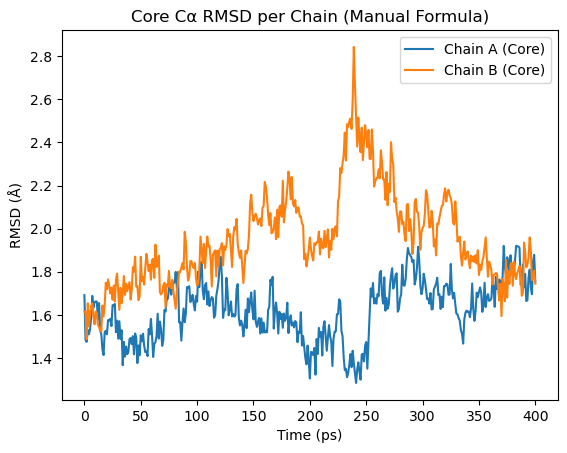

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


topology = "/home/malliga/md_analysis/conda_envs/dim.pat1.psf"
trajectory_file = "/home/malliga/md_analysis/conda_envs/prod_protein.xtc"
reference_file = "/home/malliga/md_analysis/conda_envs/em_protein.gro"

ref = mda.Universe(topology, reference_file)
trajA = mda.Universe(topology, trajectory_file)
trajB = mda.Universe(topology, trajectory_file)

core_residues = [
    13,14,15,16,17,18,19,30,31,32,33,34,35,
    71,72,74,110,111,112,113,114,115,116,117,
    118,119,120,161,163,177,178,179,180,181,
    182,183,184,185,186,187,188,189
]
core_str = " ".join(map(str, core_residues))

coreA_sel = f"segid 3CGA and resid {core_str} and name CA"
coreB_sel = f"segid 3CGB and resid {core_str} and name CA"


# Chain A (CORE RMSD)

align.AlignTraj(trajA, ref, select=coreA_sel, in_memory=True).run()

ref_coreA = ref.select_atoms(coreA_sel).positions.copy()
coreA = trajA.select_atoms(coreA_sel)

rmsd_coreA = []
time_values = []

for ts in trajA.trajectory:
    diff = coreA.positions - ref_coreA
    rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))  # formula
    rmsd_coreA.append(rmsd)
    time_values.append(ts.time)


#  Chain B (CORE RMSD)

align.AlignTraj(trajB, ref, select=coreB_sel, in_memory=True).run()

ref_coreB = ref.select_atoms(coreB_sel).positions.copy()
coreB = trajB.select_atoms(coreB_sel)

rmsd_coreB = []

for ts in trajB.trajectory:
    diff = coreB.positions - ref_coreB
    rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))  # formula
    rmsd_coreB.append(rmsd)


df = pd.DataFrame({
    "Time (ps)": time_values,
    "RMSD_CoreA (Å)": rmsd_coreA,
    "RMSD_CoreB (Å)": rmsd_coreB
})

df.to_csv("rmsd_core_manual.csv", index=False)

print("Core RMSD (Manual Formula)")
print(f"Chain A  Min: {np.min(rmsd_coreA):.3f} Å, Max: {np.max(rmsd_coreA):.3f} Å, Avg: {np.mean(rmsd_coreA):.3f} Å")
print(f"Chain B  Min: {np.min(rmsd_coreB):.3f} Å, Max: {np.max(rmsd_coreB):.3f} Å, Avg: {np.mean(rmsd_coreB):.3f} Å")


plt.figure()

plt.plot(time_values, rmsd_coreA, label="Chain A (Core)")
plt.plot(time_values, rmsd_coreB, label="Chain B (Core)")

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.title("Core Cα RMSD per Chain (Manual Formula)")
plt.legend()

plt.savefig("rmsd_core_manual.png", dpi=300)
plt.show()
plt.close()

Core RMSF (Core-Aligned)
Chain A Avg: 0.486 Å | Max: 1.085 Å
Chain B Avg: 0.496 Å | Max: 1.059 Å


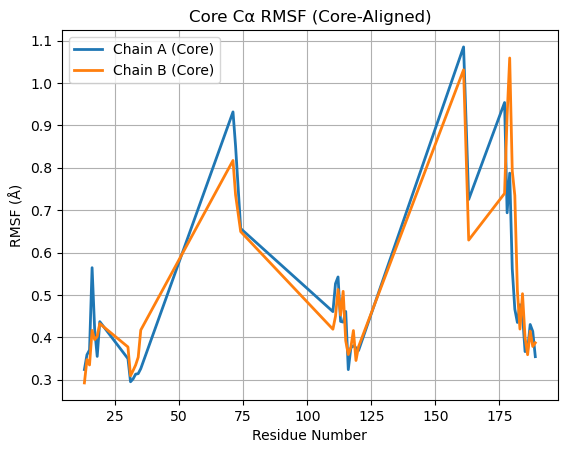

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


topology = "/home/malliga/md_analysis/conda_envs/dim.pat1.psf"
trajectory = "/home/malliga/md_analysis/conda_envs/prod_protein.xtc"
reference = "/home/malliga/md_analysis/conda_envs/em_protein.gro"


ref = mda.Universe(topology, reference)

trajA = mda.Universe(topology, trajectory)
trajB = mda.Universe(topology, trajectory)


core_residues = [
    13,14,15,16,17,18,19,30,31,32,33,34,35,
    71,72,74,110,111,112,113,114,115,116,117,
    118,119,120,161,163,177,178,179,180,181,
    182,183,184,185,186,187,188,189
]
core_str = " ".join(map(str, core_residues))

# -----------------------------
# Core selections ONLY
# -----------------------------
coreA_sel = f"segid 3CGA and resid {core_str} and name CA"
coreB_sel = f"segid 3CGB and resid {core_str} and name CA"


# Chain A (Core RMSF)

align.AlignTraj(trajA, ref, select=coreA_sel, in_memory=True).run()

coreA = trajA.select_atoms(coreA_sel)

posA = []
for ts in trajA.trajectory:
    posA.append(coreA.positions.copy())

posA = np.array(posA)

avgA = np.mean(posA, axis=0)
diffA = posA - avgA
rmsf_A = np.sqrt(np.mean(np.sum(diffA**2, axis=2), axis=0))

resids_A = coreA.resids


#  Chain B (Core RMSF)

align.AlignTraj(trajB, ref, select=coreB_sel, in_memory=True).run()

coreB = trajB.select_atoms(coreB_sel)

posB = []
for ts in trajB.trajectory:
    posB.append(coreB.positions.copy())

posB = np.array(posB)

avgB = np.mean(posB, axis=0)
diffB = posB - avgB
rmsf_B = np.sqrt(np.mean(np.sum(diffB**2, axis=2), axis=0))

resids_B = coreB.resids


df = pd.DataFrame({
    "Residue": resids_A,   # same core residues
    "RMSF_ChainA (Å)": rmsf_A,
    "RMSF_ChainB (Å)": rmsf_B
})

df.to_csv("rmsf_core_vs_core.csv", index=False)


print("Core RMSF (Core-Aligned)")
print(f"Chain A Avg: {np.mean(rmsf_A):.3f} Å | Max: {np.max(rmsf_A):.3f} Å")
print(f"Chain B Avg: {np.mean(rmsf_B):.3f} Å | Max: {np.max(rmsf_B):.3f} Å")

plt.figure()

plt.plot(resids_A, rmsf_A, lw=2, label="Chain A (Core)")
plt.plot(resids_B, rmsf_B, lw=2, label="Chain B (Core)")

plt.xlabel("Residue Number")
plt.ylabel("RMSF (Å)")
plt.title("Core Cα RMSF (Core-Aligned)")
plt.legend()
plt.grid(True)

plt.savefig("rmsf_core_manual.png", dpi=300)
plt.show()
plt.close()

Dimer RMSF (Core-Aligned)
Average RMSF: 1.305 Å
Max RMSF: 3.077 Å


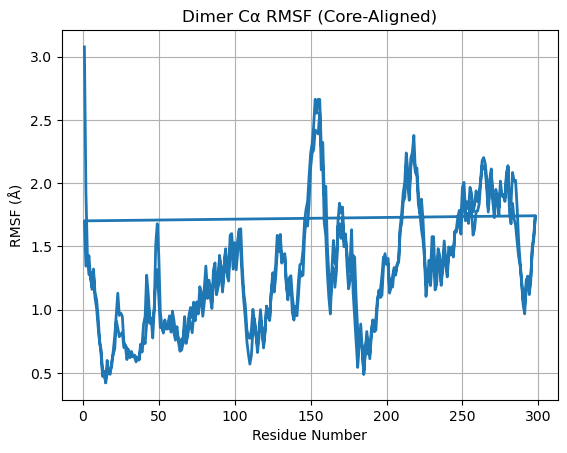

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt

topology = "/home/malliga/md_analysis/conda_envs/dim.pat1.psf"
trajectory = "/home/malliga/md_analysis/conda_envs/prod_protein.xtc"
reference = "/home/malliga/md_analysis/conda_envs/em_protein.gro"

ref = mda.Universe(topology, reference)
u = mda.Universe(topology, trajectory)




core_residues = [
    13,14,15,16,17,18,19,30,31,32,33,34,35,
    71,72,74,110,111,112,113,114,115,116,117,
    118,119,120,161,163,177,178,179,180,181,
    182,183,184,185,186,187,188,189
]
core_str = " ".join(map(str, core_residues))

# Dimer core selection (A + B)

dimer_core_sel = f"(segid 3CGA or segid 3CGB) and resid {core_str} and name CA"


align.AlignTraj(u, ref, select=dimer_core_sel, in_memory=True).run()


dimer_sel = "(segid 3CGA or segid 3CGB) and name CA"
dimer = u.select_atoms(dimer_sel)


positions = []

for ts in u.trajectory:
    positions.append(dimer.positions.copy())

positions = np.array(positions)

avg = np.mean(positions, axis=0)
diff = positions - avg
rmsf = np.sqrt(np.mean(np.sum(diff**2, axis=2), axis=0))

resids = dimer.resids

print("Dimer RMSF (Core-Aligned)")
print(f"Average RMSF: {np.mean(rmsf):.3f} Å")
print(f"Max RMSF: {np.max(rmsf):.3f} Å")


plt.figure()

plt.plot(resids, rmsf, lw=2)

plt.xlabel("Residue Number")
plt.ylabel("RMSF (Å)")
plt.title("Dimer Cα RMSF (Core-Aligned)")
plt.grid(True)

plt.show()

Core-to-Core Dimer RMSF
Average RMSF: 0.774 Å
Max RMSF: 1.631 Å


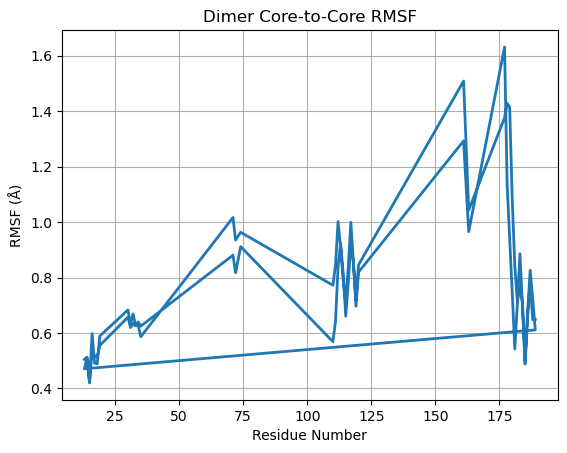

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt


topology = "/home/malliga/md_analysis/conda_envs/dim.pat1.psf"
trajectory = "/home/malliga/md_analysis/conda_envs/prod_protein.xtc"
reference = "/home/malliga/md_analysis/conda_envs/em_protein.gro"


ref = mda.Universe(topology, reference)
u = mda.Universe(topology, trajectory)


core_residues = [
    13,14,15,16,17,18,19,30,31,32,33,34,35,
    71,72,74,110,111,112,113,114,115,116,117,
    118,119,120,161,163,177,178,179,180,181,
    182,183,184,185,186,187,188,189
]
core_str = " ".join(map(str, core_residues))


core_dimer_sel = f"(segid 3CGA or segid 3CGB) and resid {core_str} and name CA"


align.AlignTraj(u, ref, select=core_dimer_sel, in_memory=True).run()


core_dimer = u.select_atoms(core_dimer_sel)

positions = []

for ts in u.trajectory:
    positions.append(core_dimer.positions.copy())

positions = np.array(positions)

avg = np.mean(positions, axis=0)
diff = positions - avg
rmsf = np.sqrt(np.mean(np.sum(diff**2, axis=2), axis=0))

resids = core_dimer.resids


print("Core-to-Core Dimer RMSF")
print(f"Average RMSF: {np.mean(rmsf):.3f} Å")
print(f"Max RMSF: {np.max(rmsf):.3f} Å")

plt.figure()

plt.plot(resids, rmsf, lw=2)

plt.xlabel("Residue Number")
plt.ylabel("RMSF (Å)")
plt.title("Dimer Core-to-Core RMSF")
plt.grid(True)

plt.show()